# Task 1: Dataset Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_support_text_classification.csv")

In [3]:
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 6)


## Dataset Size

The dataset contains multiple customer support messages along with sentiment labels for NLP classification.

In [5]:
print(df['sentiment_label'].unique())

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


## Target Variable

The target column is `sentiment_label`.

The dataset contains three sentiment classes:
- positive
- neutral
- negative

In [6]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str


## Sample Text Records

The dataset contains real-world customer support messages used for sentiment classification.

In [7]:
df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 72.75666666666666


## Average Text Length

Average text length helps understand message complexity and sequence size requirements for NLP models.

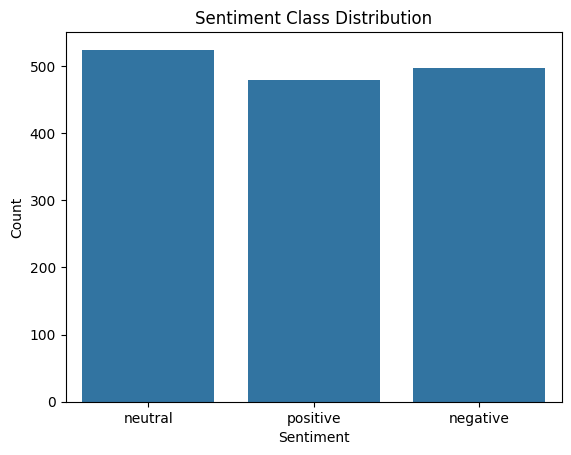

In [8]:
sns.countplot(
    x='sentiment_label',
    data=df
)

plt.title("Sentiment Class Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

## Class Distribution Analysis

The class distribution graph shows how sentiment labels are distributed across the dataset.

Balanced datasets generally improve NLP model performance.

In [9]:
print(df.isnull().sum())

ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
text_length         0
dtype: int64


## Missing Value Analysis

The dataset was checked for missing values before preprocessing and model training.

# Task 2: Text Preprocessing

In [10]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [11]:
nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayushi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aayushi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [12]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into sentence
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [14]:
import nltk

nltk.download('punkt')

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aayushi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aayushi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [16]:
stop_words = set(stopwords.words('english'))

print(stop_words)

{"he's", 'at', 'under', "i've", "wasn't", 'whom', "wouldn't", 'yours', 'with', 'against', "that'll", 'why', 'mustn', 'aren', 'himself', 'below', 'doing', "they'd", 'won', 'while', 'we', 'each', 'those', 'its', 'o', 'by', "don't", 'on', 'these', "mightn't", 'has', 'too', 'again', 'ours', 'to', 'what', 'and', "doesn't", "hasn't", "shouldn't", 'themselves', 'into', 'll', 'such', 'after', 'd', 'didn', "she'd", 'ourselves', 'does', 'shan', "hadn't", "he'd", "shan't", 'herself', 'who', 'so', 't', 'wasn', 'until', "it'd", "haven't", "needn't", 'off', 'haven', 'an', 'did', 've', 'where', 'before', 'his', "he'll", 'our', 'y', 'in', 'nor', 're', 'them', 'your', 'hasn', 'wouldn', 'if', 'needn', 'here', 'further', 'just', 'through', 'couldn', 'few', 'her', "we've", "i'll", "they've", 'be', "isn't", 'only', 'between', 'once', 'more', 'but', 'should', 'my', 'have', 'because', 'any', 'out', "they'll", "i'm", 'weren', 'hadn', "aren't", 'ma', 'about', 'having', 'ain', 'being', 'were', 's', 'me', 'their

In [17]:
df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [18]:
sample_text = df['cleaned_text'][0]

tokens = word_tokenize(sample_text)

print(tokens)

['need', 'information', 'payment', 'process', 'ticket', 'number', 'please', 'respond', 'soon', 'possible']


## Tokenization

Tokenization splits text into smaller units called tokens (words).

This helps NLP models process text data numerically.

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(df['sentiment_label'])

print(df[['sentiment_label', 'encoded_label']].head())

  sentiment_label  encoded_label
0         neutral              1
1         neutral              1
2        positive              2
3        negative              0
4         neutral              1


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

print(sequences[:3])

[[14, 104, 64, 18, 1, 2, 3, 4, 5, 6], [14, 104, 64, 18], [13, 18, 37, 38, 15, 16, 9]]


In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 20

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(X.shape)

(1500, 20)


## Sequence Padding

Text sequences were padded to equal length so they can be processed efficiently by deep learning models such as RNNs and LSTMs.

# Task 3: Text Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [24]:
X_tfidf = tfidf.fit_transform(df['cleaned_text'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (1500, 146)


In [25]:
print(tfidf.get_feature_names_out()[:20])

['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']


## Why Text Must Be Converted Into Vectors

Machine learning and deep learning models cannot understand raw text directly.

Text vectorization converts words into numerical representations that models can process mathematically.

TF-IDF helps identify important words in a document while reducing the importance of very common words.

## Sequence-Based Representation

Tokenizer-based sequences preserve word order information.

This is important for sequence models such as:
- RNN
- LSTM
- GRU

Sequence models learn contextual relationships between words more effectively than traditional vectorization techniques.

# Task 4: Baseline Model

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X = X_tfidf

y = df['encoded_label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression()


In [32]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

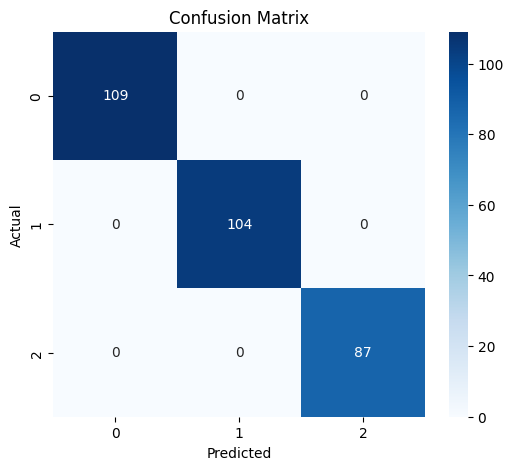

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/model_evaluation.png")

plt.show()

In [44]:
sample_predictions = """
Text: The refund process was smooth and fast
Prediction: Positive

Text: I am unhappy with the delayed support
Prediction: Negative

Text: Please provide information about my account
Prediction: Neutral
"""

with open("results/sample_predictions.txt", "w") as f:
    f.write(sample_predictions)

print("sample_predictions.txt created successfully")

sample_predictions.txt created successfully


## Model Evaluation

The Logistic Regression model was trained using TF-IDF vectorized text features.

The model achieved good classification performance on customer support sentiment prediction.

The confusion matrix and classification report show how well the model classified positive, negative, and neutral sentiments.

# Task 5: Sequence Model (LSTM Architecture)

In [38]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

In [39]:
vocab_size = 5000

In [40]:
lstm_model = Sequential([
    
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),
    
    LSTM(64),
    
    Dense(32, activation='relu'),
    
    Dense(3, activation='softmax')
])

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## LSTM Sequence Model Architecture

The sequence model processes text data in sequential form.

### Architecture Components

- **Input Sequence:** Padded tokenized text sequences
- **Embedding Layer:** Converts word indices into dense vector representations
- **LSTM Layer:** Learns contextual and sequential relationships between words
- **Dense Layer:** Performs classification using learned features
- **Output Layer:** Uses softmax activation for multi-class sentiment prediction

### Loss Function

`sparse_categorical_crossentropy`

Used because the task is multi-class classification.

### Evaluation Metric

`accuracy`

Measures how many predictions were correctly classified.

# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Traditional Recurrent Neural Networks (RNNs) process text sequentially and pass information from one step to the next. 

However, as sequences become longer, earlier information gradually becomes weaker. This problem is known as the vanishing gradient problem. Because of this, RNNs struggle to remember important information from earlier parts of long sentences or documents.

---

## How LSTMs Help with Memory

Long Short-Term Memory networks (LSTMs) are designed to solve the memory limitations of standard RNNs.

LSTMs use special memory cells and gates:
- Forget gate
- Input gate
- Output gate

These gates help the model decide:
- what information to keep
- what information to forget
- what information to pass forward

This allows LSTMs to capture long-term dependencies more effectively.

---

## What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms allow models to focus on the most important words or parts of the input sequence while generating predictions.

Instead of relying only on the final hidden state, attention gives the model direct access to relevant information from all positions in the sequence.

This improves performance in tasks such as:
- Machine translation
- Text summarization
- Question answering

---

## Why Transformers Are Important in Modern NLP and Generative AI

Transformers are modern deep learning architectures based entirely on attention mechanisms.

Unlike RNNs, transformers process all words in parallel, making training faster and more efficient.

Transformers are important because they:
- handle long-range dependencies effectively
- scale well to large datasets
- achieve state-of-the-art performance in NLP tasks

Modern Generative AI systems such as:
- ChatGPT
- GPT models
- BERT
- Gemini

are all based on transformer architectures.